<a href="https://colab.research.google.com/github/ParthHarde/breast-cancer-project/blob/main/metabric/01_metabric_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/breast-cancer-project/metabric"
for sub in ["data/raw", "data/processed", "models", "results"]:
    os.makedirs(f"{BASE}/{sub}", exist_ok=True)
print(os.listdir(BASE))

Mounted at /content/drive
['data', 'models', 'results']


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"parthharde","key":"af3528307f964a92be35e496d56da9d3"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d raghadalharbi/breast-cancer-gene-expression-profiles-metabric -p "{BASE}/data/raw" --unzip
!ls -lh "{BASE}/data/raw"

Dataset URL: https://www.kaggle.com/datasets/raghadalharbi/breast-cancer-gene-expression-profiles-metabric
License(s): DbCL-1.0
100% 2.72M/2.72M [00:00<00:00, 88.2MB/s]

total 8.1M
-rw------- 1 root root 8.1M Oct  7 04:03 METABRIC_RNA_Mutation.csv


In [5]:
import pandas as pd
df = pd.read_csv(f"{BASE}/data/raw/METABRIC_RNA_Mutation.csv", low_memory=False)
print(df.shape)
df.head()

(1904, 693)


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.info(max_cols=40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(190)
memory usage: 10.1+ MB


In [7]:
print(list(df.columns[:35]))

['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc', 'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months', 'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype', 'tumor_size', 'tumor_stage', 'death_from_cancer', 'brca1', 'brca2', 'palb2', 'pten']


In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({"missing": missing, "percent": missing_pct}).head(15))

                                missing  percent
tumor_stage                         501     26.3
3-gene_classifier_subtype           204     10.7
primary_tumor_laterality            106      5.6
neoplasm_histologic_grade            72      3.8
cellularity                          54      2.8
mutation_count                       45      2.4
er_status_measured_by_ihc            30      1.6
type_of_breast_surgery               22      1.2
tumor_size                           20      1.1
oncotree_code                        15      0.8
tumor_other_histologic_subtype       15      0.8
cancer_type_detailed                 15      0.8
death_from_cancer                     1      0.1
akr1c1                                0      0.0
akr1c2                                0      0.0


In [9]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate patient IDs:", df["patient_id"].duplicated().sum())

Duplicate rows: 0
Duplicate patient IDs: 0


In [10]:
print(df.dtypes.value_counts())   # how many numeric vs text columns

float64    498
object     190
int64        5
Name: count, dtype: int64


In [11]:
print(df.shape)

(1904, 693)


In [12]:
for col in ["overall_survival", "death_from_cancer", "overall_survival_months"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(10))


--- overall_survival ---
overall_survival
0    1103
1     801
Name: count, dtype: int64

--- death_from_cancer ---
death_from_cancer
Living                  801
Died of Disease         622
Died of Other Causes    480
NaN                       1
Name: count, dtype: int64

--- overall_survival_months ---
overall_survival_months
192.200000    4
164.333333    3
48.433333     3
34.700000     3
152.066667    3
98.700000     3
117.666667    3
150.600000    3
43.100000     3
38.033333     3
Name: count, dtype: int64


In [13]:
print(pd.crosstab(df["overall_survival"], df["death_from_cancer"], dropna=False))

death_from_cancer  Died of Disease  Died of Other Causes  Living  NaN
overall_survival                                                     
0                              622                   480       0    1
1                                0                     0     801    0


In [14]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate patient IDs:", df["patient_id"].duplicated().sum())
print(df.dtypes.value_counts())

Duplicate rows: 0
Duplicate patient IDs: 0
float64    498
object     190
int64        5
Name: count, dtype: int64


In [15]:
clinical = df.iloc[:, :31]
summary = pd.DataFrame({
    "dtype": clinical.dtypes,
    "unique_values": clinical.nunique(),
    "missing": clinical.isnull().sum()
})
print(summary)

                                  dtype  unique_values  missing
patient_id                        int64           1904        0
age_at_diagnosis                float64           1572        0
type_of_breast_surgery           object              2       22
cancer_type                      object              2        0
cancer_type_detailed             object              6       15
cellularity                      object              3       54
chemotherapy                      int64              2        0
pam50_+_claudin-low_subtype      object              7        0
cohort                          float64              5        0
er_status_measured_by_ihc        object              2       30
er_status                        object              2        0
neoplasm_histologic_grade       float64              3       72
her2_status_measured_by_snp6     object              4        0
her2_status                      object              2        0
tumor_other_histologic_subtype   object 

In [16]:
print("df loaded:", "df" in globals())
print(df.shape)
print("BASE =", BASE)

df loaded: True
(1904, 693)
BASE = /content/drive/MyDrive/breast-cancer-project/metabric


In [17]:
import numpy as np
import pandas as pd

clinical_cols = list(df.columns[:31])
genomic_cols  = list(df.columns[31:])
expr_cols = [c for c in genomic_cols if df[c].dtype != "object"]
mut_cols  = [c for c in genomic_cols if df[c].dtype == "object"]

print(len(clinical_cols), len(expr_cols), len(mut_cols))   # expect 31 489 173

31 489 173


In [18]:
for c in mut_cols[:3]:
    print(c, "->", df[c].unique()[:8])

print("Missing values in mutation columns:", df[mut_cols].isnull().sum().sum())

pik3ca_mut -> ['0' 'H1047R' 'E542K' 'Q546H G1049R' 'E545K' 'N345K E81K' 'H1047L E726K'
 'H1047L']
tp53_mut -> ['0' 'H178P' 'S241F' 'P67Qfs*56' 'C242R' 'C135R' 'S303Efs*3' 'R273C']
muc16_mut -> ['0' 'R5550S' 'P6040R' 'E2017V' 'E3861*' 'R8636I' 'S248Y' 'P6073L']
Missing values in mutation columns: 0


In [19]:
X_mut = (~df[mut_cols].astype(str).isin(["0", "0.0"])).astype(int)

print(X_mut.sum().sort_values(ascending=False).head(5))
print("Unique values in X_mut:", np.unique(X_mut.values))

pik3ca_mut    795
tp53_mut      659
muc16_mut     326
ahnak2_mut    311
kmt2c_mut     234
dtype: int64
Unique values in X_mut: [0 1]


In [20]:
target = "overall_survival"
drop_cols = ["patient_id", "cohort", "death_from_cancer",
             "overall_survival_months", target]
clinical_features = [c for c in clinical_cols if c not in drop_cols]

X = pd.concat([df[clinical_features], df[expr_cols], X_mut], axis=1)
y = df[target]

assert X.columns.is_unique
assert target not in X.columns and "death_from_cancer" not in X.columns
print(X.shape, y.shape)    # expect (1904, 688) (1904,)

(1904, 688) (1904,)


In [21]:
num_clin = [c for c in clinical_features if df[c].dtype != "object"]
cat_clin = [c for c in clinical_features if df[c].dtype == "object"]
mut_features = list(X_mut.columns)

print(len(num_clin), len(cat_clin), len(expr_cols), len(mut_features))  # expect 10 16 489 173
print("Numeric clinical:", num_clin)
print("Text clinical:", cat_clin)

10 16 489 173
Numeric clinical: ['age_at_diagnosis', 'chemotherapy', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'radio_therapy', 'tumor_size', 'tumor_stage']
Text clinical: ['type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'pam50_+_claudin-low_subtype', 'er_status_measured_by_ihc', 'er_status', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'oncotree_code', 'pr_status', '3-gene_classifier_subtype']


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_clin),
    ("cat", cat_pipe, cat_clin),
    ("expr", StandardScaler(), expr_cols),
    ("mut", "passthrough", mut_features),
])

In [23]:
import os, json

os.makedirs(f"{BASE}/data/processed", exist_ok=True)

clean = pd.concat([df[["patient_id"]], X, y], axis=1)
clean.to_csv(f"{BASE}/data/processed/metabric_clean.csv", index=False)
print(clean.shape)    # expect (1904, 690)

groups = {"num_clin": num_clin, "cat_clin": cat_clin,
          "expr_cols": expr_cols, "mut_features": mut_features}
with open(f"{BASE}/data/processed/feature_groups.json", "w") as f:
    json.dump(groups, f)

(1904, 690)


In [24]:
import numpy as np
import pandas as pd

clinical_cols = list(df.columns[:31])
genomic_cols  = list(df.columns[31:])
expr_cols = [c for c in genomic_cols if df[c].dtype != "object"]
mut_cols  = [c for c in genomic_cols if df[c].dtype == "object"]

print(len(clinical_cols), len(expr_cols), len(mut_cols))   # expect 31 489 173

31 489 173


In [25]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(X))
idx_train, idx_temp = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=42)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y.iloc[idx_temp], random_state=42)

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = X.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = X.iloc[idx_test],  y.iloc[idx_test]

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(name, len(yy), "living share:", round(yy.mean(), 3))

train 1332 living share: 0.42
val 286 living share: 0.423
test 286 living share: 0.42


In [26]:
split_df = pd.concat([
    pd.DataFrame({"patient_id": df["patient_id"].iloc[idx_train].values, "split": "train"}),
    pd.DataFrame({"patient_id": df["patient_id"].iloc[idx_val].values,   "split": "val"}),
    pd.DataFrame({"patient_id": df["patient_id"].iloc[idx_test].values,  "split": "test"}),
])
split_df.to_csv(f"{BASE}/data/processed/split_ids.csv", index=False)
print(split_df["split"].value_counts())

split
train    1332
val       286
test      286
Name: count, dtype: int64


In [27]:
preprocessor.fit(X_train)                 # learns from TRAIN only
Xtr  = preprocessor.transform(X_train)
Xval = preprocessor.transform(X_val)      # applies the same numbers, learns nothing new
Xte  = preprocessor.transform(X_test)
print(Xtr.shape, Xval.shape, Xte.shape)

(1332, 748) (286, 748) (286, 748)


In [28]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, y_train)
print("Baseline validation accuracy:", round(dummy.score(Xval, y_val), 3))   # about 0.58

Baseline validation accuracy: 0.577


In [29]:
derived = ["pam50_+_claudin-low_subtype", "integrative_cluster", "3-gene_classifier_subtype"]
web_features = [c for c in num_clin + cat_clin if c not in derived]
print(len(web_features), web_features)

23 ['age_at_diagnosis', 'chemotherapy', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'radio_therapy', 'tumor_size', 'tumor_stage', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'er_status_measured_by_ihc', 'er_status', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'primary_tumor_laterality', 'oncotree_code', 'pr_status']


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

train = X_train.copy()
train["survival"] = y_train.map({0: "Deceased", 1: "Living"})

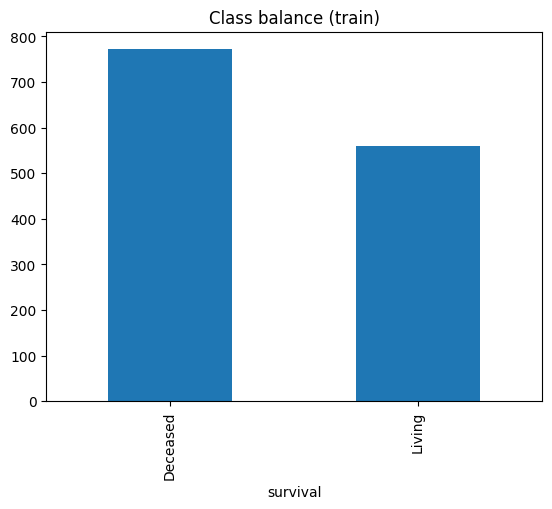

In [31]:
train["survival"].value_counts().plot(kind="bar", title="Class balance (train)")
plt.show()

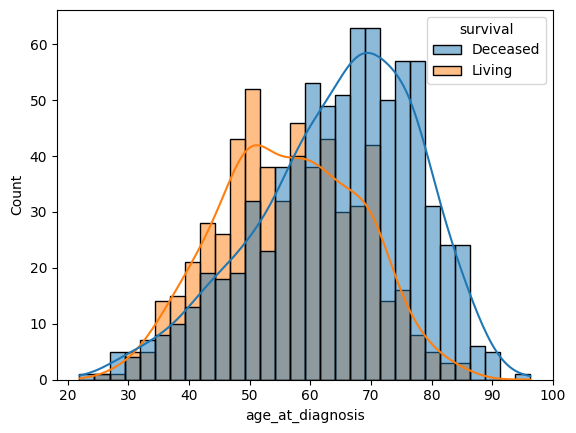

In [32]:
sns.histplot(data=train, x="age_at_diagnosis", hue="survival", kde=True, bins=30)
plt.show()

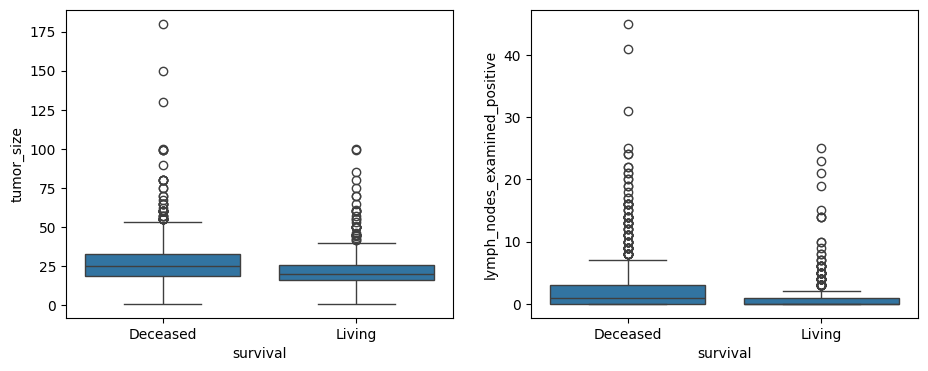

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=train, x="survival", y="tumor_size", ax=ax[0])
sns.boxplot(data=train, x="survival", y="lymph_nodes_examined_positive", ax=ax[1])
plt.show()

In [34]:
for col in ["er_status", "her2_status", "chemotherapy", "tumor_stage"]:
    print(train.groupby(col)["survival"].apply(lambda s: (s == "Living").mean()).round(2), "\n")

er_status
Negative    0.44
Positive    0.41
Name: survival, dtype: float64 

her2_status
Negative    0.43
Positive    0.36
Name: survival, dtype: float64 

chemotherapy
0    0.41
1    0.48
Name: survival, dtype: float64 

tumor_stage
0.0    0.50
1.0    0.55
2.0    0.39
3.0    0.26
4.0    0.11
Name: survival, dtype: float64 



In [35]:
num_train = X_train[num_clin].copy()
num_train["target"] = y_train
print(num_train.corr()["target"].drop("target").sort_values())

age_at_diagnosis                -0.304134
tumor_stage                     -0.191115
lymph_nodes_examined_positive   -0.175968
tumor_size                      -0.171307
nottingham_prognostic_index     -0.151983
neoplasm_histologic_grade       -0.090117
mutation_count                  -0.078506
hormone_therapy                 -0.045233
chemotherapy                     0.058588
radio_therapy                    0.101756
Name: target, dtype: float64


In [36]:
print((X_train[num_clin + cat_clin].isnull().mean() * 100).round(1).sort_values(ascending=False).head(8))

tumor_stage                  26.1
3-gene_classifier_subtype    10.7
primary_tumor_laterality      5.1
neoplasm_histologic_grade     3.6
cellularity                   2.4
mutation_count                2.3
er_status_measured_by_ihc     1.2
tumor_size                    0.9
dtype: float64


In [37]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

def dense(a):
    return a.toarray() if hasattr(a, "toarray") else a

Xtr, Xval = dense(Xtr), dense(Xval)
print(Xtr.shape, Xval.shape)          # expect (1332, 748) (286, 748)

results = []   # every experiment gets logged here

def log_result(name, y_true, proba, feature_set, split, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    results.append({
        "model": name, "features": feature_set, "split": split,
        "accuracy": accuracy_score(y_true, pred),
        "precision_deceased": precision_score(y_true, pred, pos_label=0, zero_division=0),
        "recall_deceased": recall_score(y_true, pred, pos_label=0),
        "f1_deceased": f1_score(y_true, pred, pos_label=0),
        "roc_auc": roc_auc_score(y_true, proba),
    })

(1332, 748) (286, 748)


In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, y_train)
log_result("Baseline (always deceased)", y_val, dummy.predict_proba(Xval)[:, 1], "full", "validation")

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                             eval_metric="logloss", random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
}

for name, m in models.items():
    m.fit(Xtr, y_train)                                               # TRAINING
    log_result(name, y_train, m.predict_proba(Xtr)[:, 1], "full", "train")
    log_result(name, y_val,   m.predict_proba(Xval)[:, 1], "full", "validation")
    print("done:", name)

res = pd.DataFrame(results).round(3)
res[res.split == "validation"].sort_values("roc_auc", ascending=False)

done: Logistic Regression
done: Random Forest
done: XGBoost
done: SVM (RBF)


,model,features,split,accuracy,precision_deceased,recall_deceased,f1_deceased,roc_auc
6,XGBoost,full,validation,0.717,0.741,0.782,0.761,0.771
8,SVM (RBF),full,validation,0.710,0.728,0.794,0.759,0.765
4,Random Forest,full,validation,0.717,0.702,0.885,0.783,0.738
2,Logistic Regression,full,validation,0.629,0.690,0.648,0.669,0.693
0,Baseline (always deceased),full,validation,0.577,0.577,1.000,0.732,0.500


In [39]:
res.pivot_table(index=["model", "features"], columns="split", values="roc_auc").round(3)

,split,train,validation
model,features,,
Baseline (always deceased),full,NaN,0.500
Logistic Regression,full,0.997,0.693
Random Forest,full,1.000,0.738
SVM (RBF),full,0.987,0.765
XGBoost,full,1.000,0.771


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

derived = ["pam50_+_claudin-low_subtype", "integrative_cluster", "3-gene_classifier_subtype"]
web_num = [c for c in num_clin if c != "mutation_count"]
web_cat = [c for c in cat_clin if c not in derived]
web_features = web_num + web_cat
print(len(web_num), len(web_cat), web_features)

preprocessor_web = ColumnTransformer([
    ("num", num_pipe, web_num),
    ("cat", cat_pipe, web_cat),
], sparse_threshold=0)

preprocessor_web.fit(X_train[web_features])          # fitted on TRAIN only
Xtr_w  = dense(preprocessor_web.transform(X_train[web_features]))
Xval_w = dense(preprocessor_web.transform(X_val[web_features]))
print(Xtr_w.shape, Xval_w.shape)

models_web = {}
for name, m in models.items():
    mw = clone(m).fit(Xtr_w, y_train)
    models_web[name] = mw
    log_result(name, y_train, mw.predict_proba(Xtr_w)[:, 1], "web (clinical only)", "train")
    log_result(name, y_val,   mw.predict_proba(Xval_w)[:, 1], "web (clinical only)", "validation")

res = pd.DataFrame(results).round(3)
res[res.split == "validation"].sort_values(["features", "roc_auc"], ascending=[True, False])

9 13 ['age_at_diagnosis', 'chemotherapy', 'neoplasm_histologic_grade', 'hormone_therapy', 'lymph_nodes_examined_positive', 'nottingham_prognostic_index', 'radio_therapy', 'tumor_size', 'tumor_stage', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'er_status_measured_by_ihc', 'er_status', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'primary_tumor_laterality', 'oncotree_code', 'pr_status']
(1332, 61) (286, 61)


,model,features,split,accuracy,precision_deceased,recall_deceased,f1_deceased,roc_auc
6,XGBoost,full,validation,0.717,0.741,0.782,0.761,0.771
8,SVM (RBF),full,validation,0.710,0.728,0.794,0.759,0.765
4,Random Forest,full,validation,0.717,0.702,0.885,0.783,0.738
2,Logistic Regression,full,validation,0.629,0.690,0.648,0.669,0.693
0,Baseline (always deceased),full,validation,0.577,0.577,1.000,0.732,0.500
14,XGBoost,web (clinical only),validation,0.689,0.721,0.752,0.736,0.748
16,SVM (RBF),web (clinical only),validation,0.675,0.696,0.776,0.734,0.745
10,Logistic Regression,web (clinical only),validation,0.706,0.737,0.764,0.750,0.742
12,Random Forest,web (clinical only),validation,0.699,0.718,0.788,0.751,0.740


In [41]:
res.to_csv(f"{BASE}/results/validation_results_day1.csv", index=False)

In [42]:
import tensorflow as tf
from tensorflow import keras

def build_nn(input_dim, lr=0.001, dropout=0.3):
    keras.utils.set_random_seed(42)
    m = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

def train_nn(m, Xa, ya, Xb, yb, epochs=100, batch_size=32):
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                       restore_best_weights=True)
    return m.fit(Xa.astype("float32"), ya.values,
                 validation_data=(Xb.astype("float32"), yb.values),
                 epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=0)

def plot_history(h):
    plt.plot(h.history["loss"], label="train loss")
    plt.plot(h.history["val_loss"], label="validation loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

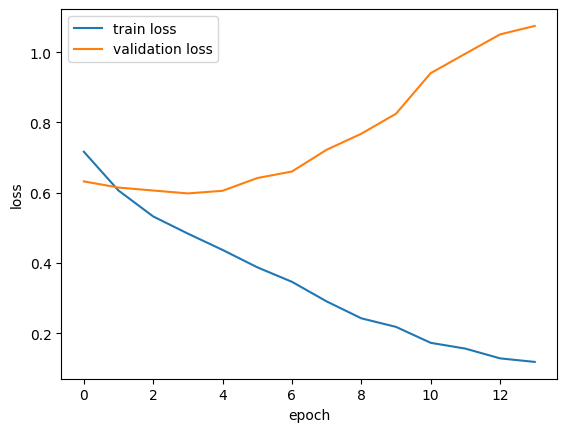

stopped after 14 epochs


In [43]:
nn = build_nn(Xtr.shape[1])
h = train_nn(nn, Xtr, y_train, Xval, y_val)
plot_history(h)
print("stopped after", len(h.history["loss"]), "epochs")

log_result("Neural network", y_train, nn.predict(Xtr.astype("float32"), verbose=0).ravel(), "full", "train")
log_result("Neural network", y_val,   nn.predict(Xval.astype("float32"), verbose=0).ravel(), "full", "validation")

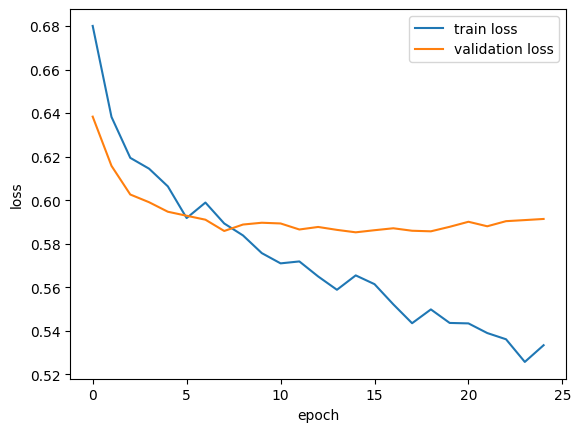

In [44]:
nn_w = build_nn(Xtr_w.shape[1])
h_w = train_nn(nn_w, Xtr_w, y_train, Xval_w, y_val)
plot_history(h_w)
log_result("Neural network", y_train, nn_w.predict(Xtr_w.astype("float32"), verbose=0).ravel(), "web (clinical only)", "train")
log_result("Neural network", y_val,   nn_w.predict(Xval_w.astype("float32"), verbose=0).ravel(), "web (clinical only)", "validation")

In [45]:
for lr in [0.1, 0.001, 0.00001]:
    m = build_nn(Xtr.shape[1], lr=lr)
    hh = train_nn(m, Xtr, y_train, Xval, y_val, epochs=60)
    print(f"lr={lr}: best val loss = {min(hh.history['val_loss']):.3f}, epochs run = {len(hh.history['loss'])}")

lr=0.1: best val loss = 0.681, epochs run = 37
lr=0.001: best val loss = 0.598, epochs run = 14
lr=1e-05: best val loss = 0.648, epochs run = 60


In [46]:
res = pd.DataFrame(results).round(3)
res.to_csv(f"{BASE}/results/validation_results_day2.csv", index=False)
res[res.split == "validation"].sort_values(["features", "roc_auc"], ascending=[True, False])

,model,features,split,accuracy,precision_deceased,recall_deceased,f1_deceased,roc_auc
6,XGBoost,full,validation,0.717,0.741,0.782,0.761,0.771
8,SVM (RBF),full,validation,0.710,0.728,0.794,0.759,0.765
4,Random Forest,full,validation,0.717,0.702,0.885,0.783,0.738
18,Neural network,full,validation,0.682,0.720,0.733,0.727,0.729
2,Logistic Regression,full,validation,0.629,0.690,0.648,0.669,0.693
0,Baseline (always deceased),full,validation,0.577,0.577,1.000,0.732,0.500
20,Neural network,web (clinical only),validation,0.713,0.737,0.782,0.759,0.755
14,XGBoost,web (clinical only),validation,0.689,0.721,0.752,0.736,0.748
16,SVM (RBF),web (clinical only),validation,0.675,0.696,0.776,0.734,0.745
10,Logistic Regression,web (clinical only),validation,0.706,0.737,0.764,0.750,0.742


In [ ]:
best = models["XGBoost"]          # change to your best, e.g. models["Random Forest"]

In [47]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

rows = []
for name, m in models.items():
    pipe = Pipeline([("prep", clone(preprocessor_web)), ("model", clone(m))])
    scores = cross_val_score(pipe, X_train[web_features], y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    rows.append({"model": name, "mean_auc": scores.mean(), "std": scores.std()})
    print("done:", name)

cv_table = pd.DataFrame(rows).sort_values("mean_auc", ascending=False).round(3)
cv_table

done: Logistic Regression
done: Random Forest
done: XGBoost
done: SVM (RBF)


,model,mean_auc,std
0,Logistic Regression,0.730,0.028
2,XGBoost,0.729,0.024
3,SVM (RBF),0.729,0.039
1,Random Forest,0.716,0.033


In [48]:
res = pd.DataFrame(results).round(3)
res.pivot_table(index=["features", "model"], columns="split", values="roc_auc").round(3)

split                                           train  validation
features            model                                        
full                Baseline (always deceased)    NaN       0.500
                    Logistic Regression         0.997       0.693
                    Neural network              0.950       0.729
                    Random Forest               1.000       0.738
                    SVM (RBF)                   0.987       0.765
                    XGBoost                     1.000       0.771
web (clinical only) Logistic Regression         0.762       0.742
                    Neural network              0.808       0.755
                    Random Forest               1.000       0.740
                    SVM (RBF)                   0.834       0.745
                    XGBoost                     0.882       0.748

In [49]:
rows = []
for name in ["Logistic Regression", "XGBoost", "SVM (RBF)"]:
    pipe = Pipeline([("prep", clone(preprocessor)), ("model", clone(models[name]))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    rows.append({"model": name, "mean_auc": scores.mean(), "std": scores.std()})
    print("done:", name)
pd.DataFrame(rows).sort_values("mean_auc", ascending=False).round(3)

done: Logistic Regression
done: XGBoost
done: SVM (RBF)


,model,mean_auc,std
2,SVM (RBF),0.747,0.041
1,XGBoost,0.741,0.037
0,Logistic Regression,0.669,0.026


In [50]:
best_w = models_web["XGBoost"]    # untuned web model; swap in the tuned one after Step 10

def predict_p(d):
    """raw patient rows -> P(living)"""
    return best_w.predict_proba(dense(preprocessor_web.transform(d[web_features])))[:, 1]

p_val = predict_p(X_val)
pred_val = (p_val >= 0.5).astype(int)

In [51]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_lr = Pipeline([("prep", clone(preprocessor_web)),
                    ("model", LogisticRegression(max_iter=5000, random_state=42))])

grid_lr = GridSearchCV(pipe_lr,
                       {"model__C": [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1]},
                       cv=cv5, scoring="roc_auc", n_jobs=-1, return_train_score=True)
grid_lr.fit(X_train[web_features], y_train)

print("best:", grid_lr.best_params_, "CV AUC:", round(grid_lr.best_score_, 3))
pd.DataFrame(grid_lr.cv_results_)[["param_model__C", "mean_train_score",
                                    "mean_test_score", "std_test_score"]].round(3)

best: {'model__C': 0.03} CV AUC: 0.731


,param_model__C,mean_train_score,mean_test_score,std_test_score
0,0.000,0.727,0.719,0.036
1,0.001,0.731,0.721,0.036
2,0.003,0.739,0.725,0.036
3,0.010,0.748,0.729,0.036
4,0.030,0.755,0.731,0.034
5,0.100,0.761,0.731,0.032
6,0.300,0.763,0.729,0.030
7,1.000,0.765,0.729,0.028


In [52]:
param_xgb = {
    "model__n_estimators":     [100, 200, 300, 500],
    "model__learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "model__max_depth":        [2, 3, 4, 5],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample":        [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.8, 1.0],
    "model__reg_lambda":       [1, 5, 10],
}
pipe_xgb = Pipeline([("prep", clone(preprocessor_web)),
                     ("model", XGBClassifier(eval_metric="logloss", random_state=42))])

rs_xgb = RandomizedSearchCV(pipe_xgb, param_xgb, n_iter=40, cv=cv5,
                            scoring="roc_auc", n_jobs=-1, random_state=42,
                            return_train_score=True)
rs_xgb.fit(X_train[web_features], y_train)

print("best:", rs_xgb.best_params_, "CV AUC:", round(rs_xgb.best_score_, 3))
r = pd.DataFrame(rs_xgb.cv_results_).sort_values("mean_test_score", ascending=False)
r[["mean_train_score", "mean_test_score", "std_test_score", "param_model__max_depth",
   "param_model__learning_rate", "param_model__n_estimators"]].head(5).round(3)

best: {'model__subsample': 0.8, 'model__reg_lambda': 1, 'model__n_estimators': 200, 'model__min_child_weight': 10, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0} CV AUC: 0.746


,mean_train_score,mean_test_score,std_test_score,param_model__max_depth,param_model__learning_rate,param_model__n_estimators
6,0.872,0.746,0.033,5,0.03,200
27,0.868,0.745,0.033,5,0.03,100
22,0.810,0.744,0.029,2,0.03,300
30,0.810,0.744,0.033,3,0.01,300
5,0.875,0.743,0.029,3,0.03,500


In [53]:
for name, est in [("Logistic Regression (tuned)", grid_lr.best_estimator_),
                  ("XGBoost (tuned)", rs_xgb.best_estimator_)]:
    log_result(name, y_train, est.predict_proba(X_train[web_features])[:, 1], "web (clinical only)", "train")
    log_result(name, y_val,   est.predict_proba(X_val[web_features])[:, 1],   "web (clinical only)", "validation")

res = pd.DataFrame(results).round(3)
cols = ["model", "accuracy", "precision_deceased", "recall_deceased", "f1_deceased", "roc_auc"]
res[(res.split == "validation") & (res.features == "web (clinical only)")] \
    .sort_values("roc_auc", ascending=False)[cols]

,model,accuracy,precision_deceased,recall_deceased,f1_deceased,roc_auc
20,Neural network,0.713,0.737,0.782,0.759,0.755
22,Logistic Regression (tuned),0.703,0.720,0.794,0.755,0.749
14,XGBoost,0.689,0.721,0.752,0.736,0.748
16,SVM (RBF),0.675,0.696,0.776,0.734,0.745
24,XGBoost (tuned),0.682,0.710,0.758,0.733,0.744
10,Logistic Regression,0.706,0.737,0.764,0.750,0.742
12,Random Forest,0.699,0.718,0.788,0.751,0.740


In [54]:
def build_nn2(input_dim, units, dropout, lr):
    keras.utils.set_random_seed(42)
    layers = [keras.layers.Input(shape=(input_dim,))]
    for u in units:
        layers += [keras.layers.Dense(u, activation="relu"), keras.layers.Dropout(dropout)]
    layers.append(keras.layers.Dense(1, activation="sigmoid"))
    m = keras.Sequential(layers)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="binary_crossentropy")
    return m

configs = [
    dict(units=(64, 32),  dropout=0.3, lr=1e-3, batch=32),
    dict(units=(32,),     dropout=0.3, lr=1e-3, batch=32),
    dict(units=(128, 64), dropout=0.5, lr=1e-3, batch=32),
    dict(units=(64, 32),  dropout=0.3, lr=1e-3, batch=64),
    dict(units=(64, 32),  dropout=0.3, lr=3e-4, batch=32),
]
rows = []
for c in configs:
    m = build_nn2(Xtr_w.shape[1], c["units"], c["dropout"], c["lr"])
    h = train_nn(m, Xtr_w, y_train, Xval_w, y_val, batch_size=c["batch"])
    auc = roc_auc_score(y_val, m.predict(Xval_w.astype("float32"), verbose=0).ravel())
    rows.append({**c, "epochs": len(h.history["loss"]), "val_auc": round(auc, 3)})
pd.DataFrame(rows)

,units,dropout,lr,batch,epochs,val_auc
0,"(64, 32)",0.3,0.0010,32,25,0.755
1,"(32,)",0.3,0.0010,32,27,0.758
2,"(128, 64)",0.5,0.0010,32,28,0.759
3,"(64, 32)",0.3,0.0010,64,26,0.757
4,"(64, 32)",0.3,0.0003,32,37,0.754


In [55]:
rng = np.random.default_rng(42)
pick = rng.choice(len(y_val), size=8, replace=False)

table = pd.DataFrame({
    "patient_id": df["patient_id"].iloc[idx_val].values[pick],
    "age": X_val["age_at_diagnosis"].values[pick].round(1),
    "tumor_size": X_val["tumor_size"].values[pick],
    "true": y_val.values[pick],
    "pred": pred_val[pick],
    "P(living)": p_val[pick].round(2),
})
table["correct"] = table["true"] == table["pred"]
table

,patient_id,age,tumor_size,true,pred,P(living),correct
0,5013,68.6,20.0,0,0,0.38,True
1,316,50.8,30.0,1,1,0.72,True
2,880,73.6,30.0,1,0,0.22,False
3,3452,64.0,30.0,0,0,0.35,True
4,3110,61.1,16.0,1,1,0.52,True
5,5346,52.1,80.0,1,0,0.36,False
6,4222,58.8,40.0,0,0,0.39,True
7,5124,84.0,26.0,0,0,0.16,True


In [56]:
row = X_val.iloc[[0]].copy()
for age in [35, 55, 80]:
    r = row.copy()
    r["age_at_diagnosis"] = age
    print(f"age {age}: P(living) = {predict_p(r)[0]:.2f}")

age 35: P(living) = 0.77
age 55: P(living) = 0.68
age 80: P(living) = 0.15


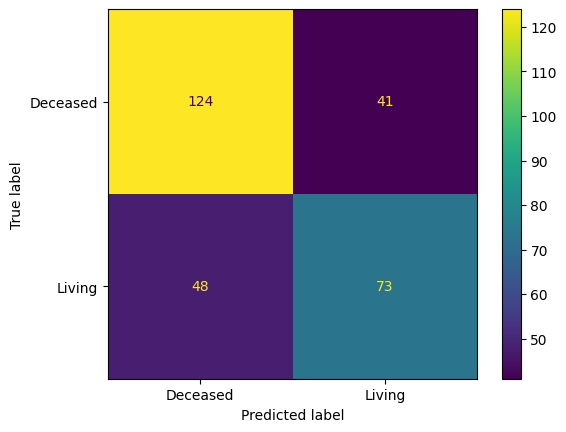

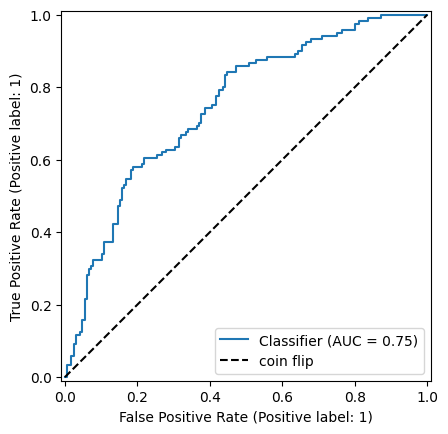

              precision    recall  f1-score   support

    Deceased       0.72      0.75      0.74       165
      Living       0.64      0.60      0.62       121

    accuracy                           0.69       286
   macro avg       0.68      0.68      0.68       286
weighted avg       0.69      0.69      0.69       286

ROC-AUC: 0.748


In [57]:
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report, roc_auc_score)

ConfusionMatrixDisplay.from_predictions(y_val, pred_val, display_labels=["Deceased", "Living"])
plt.show()

RocCurveDisplay.from_predictions(y_val, p_val)
plt.plot([0, 1], [0, 1], "k--", label="coin flip"); plt.legend(); plt.show()

print(classification_report(y_val, pred_val, target_names=["Deceased", "Living"]))
print("ROC-AUC:", round(roc_auc_score(y_val, p_val), 3))

In [58]:
errors = X_val.copy()
errors["true"] = y_val.values
errors["wrong"] = (pred_val != y_val.values)

print(errors.groupby("wrong")[["age_at_diagnosis", "tumor_size", "lymph_nodes_examined_positive"]].mean().round(1))
print(pd.crosstab(errors["er_status"], errors["wrong"], normalize="index").round(2))

       age_at_diagnosis  tumor_size  lymph_nodes_examined_positive
wrong                                                             
False              61.7        27.0                            2.2
True               58.5        27.4                            1.6
wrong      False  True 
er_status              
Negative    0.70   0.30
Positive    0.69   0.31


In [59]:
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pr = (p_val >= t).astype(int)
    rows.append({"threshold": t,
                 "recall_deceased": recall_score(y_val, pr, pos_label=0),
                 "precision_deceased": precision_score(y_val, pr, pos_label=0, zero_division=0)})
pd.DataFrame(rows).round(3)

,threshold,recall_deceased,precision_deceased
0,0.3,0.467,0.837
1,0.4,0.612,0.754
2,0.5,0.752,0.721
3,0.6,0.855,0.681
4,0.7,0.933,0.644


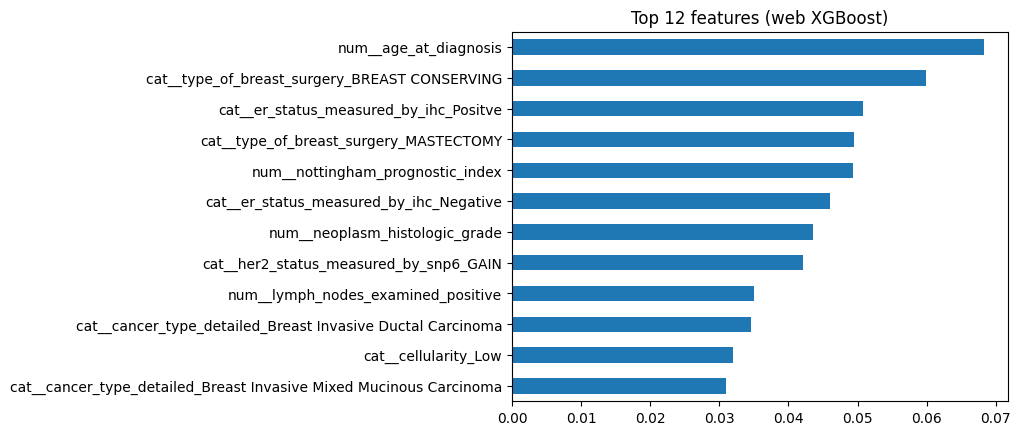

In [60]:
names = preprocessor_web.get_feature_names_out()
imp = pd.Series(models_web["XGBoost"].feature_importances_, index=names).sort_values(ascending=False).head(12)
imp.plot(kind="barh", title="Top 12 features (web XGBoost)")
plt.gca().invert_yaxis(); plt.show()

In [61]:
errors["type"] = np.select(
    [(errors["true"] == 0) & (pred_val == 1), (errors["true"] == 1) & (pred_val == 0)],
    ["False negative (died, predicted living)", "False alarm (lived, predicted deceased)"],
    default="Correct")
print(errors["type"].value_counts())
print(errors.groupby("type")[["age_at_diagnosis", "tumor_size", "lymph_nodes_examined_positive"]].mean().round(1))

type
Correct                                    197
False alarm (lived, predicted deceased)     48
False negative (died, predicted living)     41
Name: count, dtype: int64
                                         age_at_diagnosis  tumor_size  \
type                                                                    
Correct                                              61.7        27.0   
False alarm (lived, predicted deceased)              62.2        32.4   
False negative (died, predicted living)              54.3        21.4   

                                         lymph_nodes_examined_positive  
type                                                                    
Correct                                                            2.2  
False alarm (lived, predicted deceased)                            2.2  
False negative (died, predicted living)                            0.9  
